### [주제 : 사과 & 바나나 분류 - (4) 교차검증] <hr>

- **교차검증(Cross Validation)**
    - 모델의 일반화 성능을 측정
    * 부족한 데이터셋 문제를 어느정도는 해결 가능
    * 매번 다른 검증 데이터셋으로 진행 됨
    * 관련 클래스
     - model_selcection.kFold : 희귀용
     - model_selcection.StratifiedFold : 분류용

In [5]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

import pandas as pd
import numpy as np
import cv2

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#### [1] 데이터

In [6]:
# => 이미지 관련
DATA_FILE = '../Data/fruit_data.csv'

df = pd.read_csv(DATA_FILE)

df.info()
display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Columns: 10001 entries, pixel0 to label
dtypes: int64(10000), object(1)
memory usage: 33.4+ MB


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel9991,pixel9992,pixel9993,pixel9994,pixel9995,pixel9996,pixel9997,pixel9998,pixel9999,label
0,112,113,114,116,116,118,123,129,129,131,...,83,69,61,53,48,43,41,38,36,apple
1,102,102,103,104,104,104,104,104,103,103,...,61,62,60,62,69,67,62,69,76,apple
2,48,49,51,53,54,54,55,55,55,56,...,23,24,37,49,64,85,105,112,119,apple


#### [2] 데이터와 타겟/라벨 분리

In [7]:
# => 학습 데이터와 정답지 타겟 분리
# X(픽셀데이터) / y(라벨) 분리
x = df.iloc[:,:-1].values # ndarray
y = df['label'].values    # ndarray

# => 숫자 학습 데이터는 학습 안정화를 위해서 정규화 0~1
# 3) 데이터 정규화
x = x / 255.0

print(f'정규화 후 : \n{x[:3, :]}')

정규화 후 : 
[[0.43921569 0.44313725 0.44705882 ... 0.16078431 0.14901961 0.14117647]
 [0.4        0.4        0.40392157 ... 0.24313725 0.27058824 0.29803922]
 [0.18823529 0.19215686 0.2        ... 0.41176471 0.43921569 0.46666667]]


#### [3] 학습용 / 테스트용 데이터셋 분리
* 학습용 데이터셋 => 일부를 테스트 데이터셋 사용
* 함수 : train_test_split()
    - 전체 학습용 데이터셋에 몇 %로 할지 설정 [default] 학습용 : 테스트용 = 75% : 25%
    - 데이터를 섞어 주는 작업
    - 불균형 데이터 셋에 대한 설정

In [8]:
# 4) 학습용 / 테스트용 데이터 분리 (80% : 20%)
# => 데이터 : 2D
# => 라벨 : 1D
# => 제현성 : random_state= 숫저 데이터셋을 섞지만, 매번 동일하게
# => 균현 : 데이터셋의 균형 맞추기, 분ㄴ류일때만 필요
X_train, X_test, y_train, y_test = train_test_split( x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print(f'train : {X_train.shape}, test : {X_test.shape}')

train : (350, 10000), test : (88, 10000)


### [4]모델 생성 및 학습

In [ ]:
# # => 교차 검증 기반 학습 [1] KFold
# # => K-Fold 분할 객체 생성
# kfold = KFold(n_splits=5) # 기본값
# train_scores, valid_scores = {"KNN":[], "SVC":[]}, {"KNN":[], "SVC":[]} # 점수 저장

# for train_idx, valid_idx in kfold.split(X_train):
#     # 학습용, 검증용 데이터 셋 구성
#     train_x, train_y = X_train[train_idx], y_train[train_idx]
#     valid_x, valid_y = X_train[valid_idx], y_train[valid_idx]
#     # print(f'train : {train_x.shape}, {train_y.shape}')
#     # print(f'valid : {valid_x.shape}, {valid_y.shape}')
    
#     # 학습
#     kModel= KNeighborsClassifier()
#     svcModel= SVC(kernel='linear')
    
#     kModel.fit(train_x, train_y)
#     svcModel.fit(train_x, train_y)

#     # 저장
#     train_scores["KNN"].append(kModel.score(train_x, train_y))
#     valid_scores["KNN"].append(kModel.score(valid_x, valid_y))
#     train_scores["SVC"].append(svcModel.score(train_x, train_y))
#     valid_scores["SVC"].append(svcModel.score(valid_x, valid_y))

# # => K개의 데이터셋에 대한 평가 점수 => 평균
# for key in train_scores.keys():
#     train_avg = sum(train_scores[key])/len(train_scores[key])
#     valid_avg = sum(valid_scores[key])/len(valid_scores[key])
#     print(f'학습용 평균 점수 : {train_avg:.3f}, 검증용 평균 점수 : {valid_avg:.3f}')

학습용 평균 점수 : 0.867, 검증용 평균 점수 : 0.834
학습용 평균 점수 : 1.000, 검증용 평균 점수 : 0.814


In [ ]:
# # => 교차 검증 기반 학습 [1] KFold
# # => K-Fold 분할 객체 생성
kfold = KFold(n_splits=5) # 기본값
scoreDF = pd.DataFrame(columns=["K_NO", "model", "train_score", "valid_score"])

for no, (train_idx, valid_idx) in enumerate(kfold.split(X_train), start=1):
    # 학습용, 검증용 데이터 셋 구성
    train_x, train_y = X_train[train_idx], y_train[train_idx]
    valid_x, valid_y = X_train[valid_idx], y_train[valid_idx]

    # 학습
    kModel= KNeighborsClassifier()
    svcModel= SVC(kernel='linear')
    
    kModel.fit(train_x, train_y)
    svcModel.fit(train_x, train_y)

    scoreDF.loc[f"KNN_{no}"] = [no, "KNN", kModel.score(train_x, train_y), kModel.score(valid_x, valid_y)]
    scoreDF.loc[f"SVC_{no}"] = [no, "SVC", svcModel.score(train_x, train_y), svcModel.score(valid_x, valid_y)]

scoreDF.describe()

,K_NO,train_score,valid_score
count,10.000000,10.000000,10.000000
mean,3.000000,0.933571,0.824286
std,1.490712,0.070655,0.040434
min,1.000000,0.850000,0.757143
25%,2.000000,0.865179,0.789286
50%,3.000000,0.944643,0.835714
75%,4.000000,1.000000,0.853571
max,5.000000,1.000000,0.885714


In [29]:
# # => 교차 검증 기반 학습 [2] StratifiedKFold
# # => StratifiedKFold 분할 객체 생성
skfold = StratifiedKFold(n_splits=5) # 기본값
scoreDF2 = pd.DataFrame(columns=["K_NO", "model", "train_score", "valid_score"])

for no, (train_idx, valid_idx) in enumerate(skfold.split(X_train, y_train), start=1):
    # 학습용, 검증용 데이터 셋 구성
    train_x, train_y = X_train[train_idx], y_train[train_idx]
    valid_x, valid_y = X_train[valid_idx], y_train[valid_idx]

    # 학습
    kModel= KNeighborsClassifier()
    svcModel= SVC(kernel='linear')
    
    kModel.fit(train_x, train_y)
    svcModel.fit(train_x, train_y)

    scoreDF2.loc[f"KNN_{no}"] = [no, "KNN", kModel.score(train_x, train_y), kModel.score(valid_x, valid_y)]
    scoreDF2.loc[f"SVC_{no}"] = [no, "SVC", svcModel.score(train_x, train_y), svcModel.score(valid_x, valid_y)]

scoreDF2.describe()

,K_NO,train_score,valid_score
count,10.000000,10.000000,10.000000
mean,3.000000,0.933214,0.822857
std,1.490712,0.071111,0.034470
min,1.000000,0.850000,0.757143
25%,2.000000,0.866071,0.803571
50%,3.000000,0.944643,0.828571
75%,4.000000,1.000000,0.842857
max,5.000000,1.000000,0.871429


### [5] 모델 성능 분석
- 통계 기반 분석
- 시각화 분석

In [30]:
# 통계기반 분석
resultDF = scoreDF[scoreDF.columns[1:]].groupby('model').agg(['min','max','mean','std'])
display(resultDF)

resultDF2 = scoreDF2[scoreDF2.columns[1:]].groupby('model').agg(['min','max','mean','std'])
display(resultDF2)


train_score                               valid_score            \
              min       max      mean       std         min       max   
model                                                                   
KNN          0.85  0.889286  0.867143  0.014151    0.785714  0.885714   
SVC          1.00  1.000000  1.000000  0.000000    0.757143  0.842857   

                           
           mean       std  
model                      
KNN    0.834286  0.045848  
SVC    0.814286  0.036422

train_score                               valid_score            \
              min       max      mean       std         min       max   
model                                                                   
KNN          0.85  0.889286  0.866429  0.015068    0.785714  0.871429   
SVC          1.00  1.000000  1.000000  0.000000    0.757143  0.842857   

                           
           mean       std  
model                      
KNN    0.831429  0.036978  
SVC    0.814286  0.033503

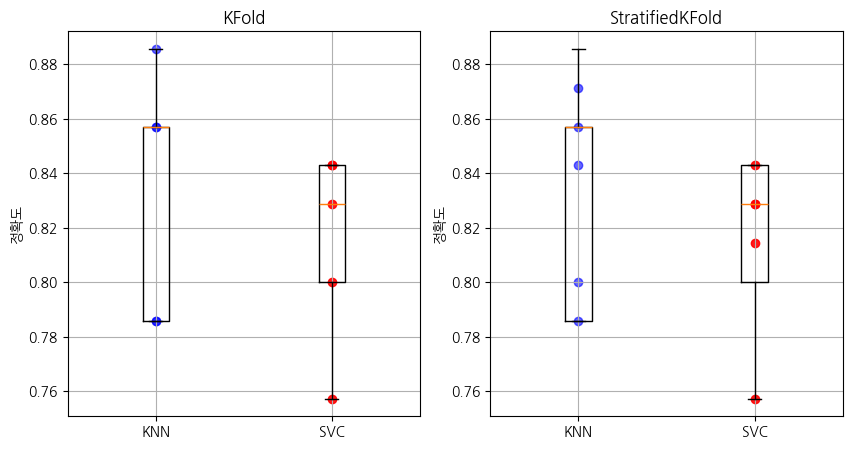

In [36]:
# 모델별 검증(valid) 점수 분포 표출
knn_scores = scoreDF[scoreDF['model'] == 'KNN']['valid_score'].values
svc_scores = scoreDF[scoreDF['model'] == 'SVC']['valid_score'].values

knn_scores2 = scoreDF2[scoreDF['model'] == 'KNN']['valid_score'].values
svc_scores2 = scoreDF2[scoreDF['model'] == 'SVC']['valid_score'].values

datas = [[knn_scores, svc_scores], [knn_scores2, svc_scores2]]
titles = ['KFold', 'StratifiedKFold']

# 시각화 : 모델별 K-Fold 검증 점수 분포 비교
fig, axes = plt.subplots(1,2, figsize=(10,5))

for ax, (knn, svc), title in zip(axes, datas, titles):
    ax.boxplot([knn_scores, svc_scores], tick_labels=['KNN', 'SVC'])
    ax.scatter([1] * len(knn), knn, color='blue', alpha=0.6)
    ax.scatter([2] * len(svc), svc, color='red', alpha=0.9)
    ax.set_ylabel('정확도')
    ax.set_title(title)
    ax.grid()
plt.show()